# Polynomial Regression and Regularization

## When is the roller-coaster queue longest?

A queue grows toward the afternoon peak and shrinks later. A straight line cannot describe both changes. Polynomial regression adds curved features of time so that the prediction can bend.

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/04_fitting_a_curve.png" alt="Simulated roller-coaster waits compared with a straight line, a smooth curve, and a highly flexible curve." width="640" style="max-width:100%;height:auto;">

Polynomial degree controls how flexible the curve can be. A higher degree can follow more turns, including turns caused by random variation. The coefficients still enter linearly, so polynomial regression belongs to the linear-model family even though its prediction is curved.


## Following a daily pattern or chasing every delay

The degree control changes the curve's flexibility. A line that misses the afternoon peak underfits. A curve that chases individual noisy records may overfit: it fits old records closely but predicts new visits poorly.

Ridge regularization discourages large coefficients. Its control can reduce unstable bends; excessive regularization can also flatten a useful pattern. The code scales the features so their penalties are comparable.

Blue records fit the model. Orange validation visits check the choice of degree and penalty. `Validation best` selects the best of four predefined candidates. Changing the controls does not change this predefined comparison. Validation error helps tune the model; an untouched test set is needed for a final evaluation.


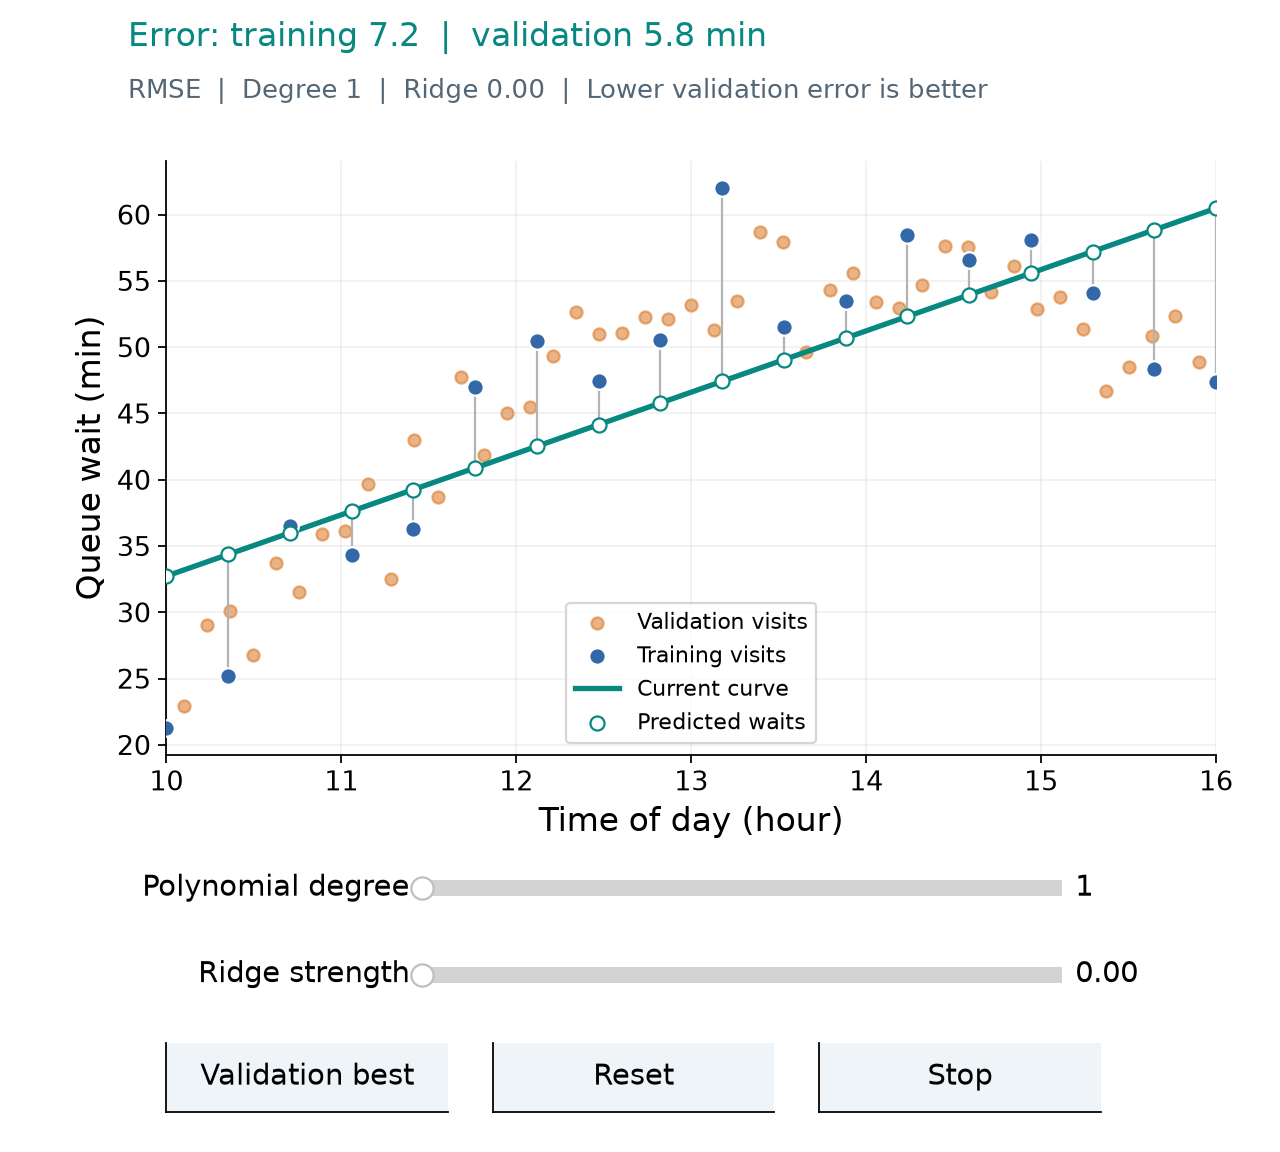

In [1]:
import os
import sys
import io
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            # The browser dispatches input after the cell returns.
            plt.show(block=False)
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show(block=False)

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

rng_park = np.random.default_rng(61)


def park_mean(hour):
    return 55 - 2 * (np.asarray(hour)-14)**2


park_train_time = np.linspace(10, 16, 18)
park_train_wait = park_mean(park_train_time) + rng_park.normal(0, 3, 18)
park_valid_time = np.linspace(10.1, 15.9, 45)
park_valid_wait = park_mean(park_valid_time) + rng_park.normal(0, 3, 45)


def polynomial_model(degree, penalty=0.0):
    regressor = Ridge(alpha=penalty) if penalty > 0 else LinearRegression()
    return make_pipeline(StandardScaler(), PolynomialFeatures(degree, include_bias=False),
                         StandardScaler(), regressor)


candidate_settings = {"Straight line": (1, 0.), "Smooth curve": (2, 0.),
                      "Flexible curve": (12, 0.), "Flexible + Ridge": (12, 1.)}
park_models, validation_errors = {}, {}
for name, (degree, penalty) in candidate_settings.items():
    model = polynomial_model(degree, penalty).fit(park_train_time[:, None], park_train_wait)
    park_models[name] = model
    validation_errors[name] = metrics(park_valid_wait, model.predict(park_valid_time[:, None]))["RMSE"]
selected_name = min(validation_errors, key=validation_errors.get)
park_grid = np.linspace(10, 16, 350)


def render_park_curve(view, degree, penalty):
    model = polynomial_model(int(degree), penalty).fit(park_train_time[:, None], park_train_wait)
    predicted_train = model.predict(park_train_time[:, None])
    train_error = metrics(park_train_wait, predicted_train)
    valid_error = metrics(park_valid_wait, model.predict(park_valid_time[:, None]))
    prediction = model.predict(park_grid[:, None])
    ax = view.ax
    ax.scatter(park_valid_time, park_valid_wait, color=ORANGE, s=30, alpha=.55, label="Validation visits")
    ax.scatter(park_train_time, park_train_wait, color=BLUE, s=55, edgecolor="white", zorder=4, label="Training visits")
    ax.plot(park_grid, prediction, color=TEAL, label="Current curve")
    ax.scatter(park_train_time, predicted_train, facecolors="white", edgecolors=TEAL,
               s=40, zorder=5, label="Predicted waits")
    ax.vlines(park_train_time, predicted_train, park_train_wait, color=".7", linewidth=1)
    ax.set(xlabel="Time of day (hour)", ylabel="Queue wait (min)", xlim=(10, 16))
    ax.legend(loc="lower center", fontsize=10)
    view.status.set_text(f"Error: training {train_error['RMSE']:.1f}  |  validation {valid_error['RMSE']:.1f} min")
    view.detail.set_text(f"RMSE  |  Degree {int(degree)}  |  Ridge {penalty:.2f}  |  Lower validation error is better")
    return {"model": model, "prediction": prediction, "training_prediction": predicted_train,
            "train_metrics": train_error, "validation_metrics": valid_error}


park_curve_demo = RegressionExplorer("park_curve", render_park_curve, [
    ("degree", "Polynomial degree", 1, 12, 1, 1, "%0.0f"),
    ("penalty", "Ridge strength", 0, 10, 0, .05, "%0.2f"),
], actions=[("Validation best", lambda view: view.set_values(
    degree=candidate_settings[selected_name][0], penalty=candidate_settings[selected_name][1]))])
park_curve_demo.start()


## Beyond the recorded setting

These synthetic visits share the same daily pattern. A ride breakdown or a surprise holiday crowd could change it. More records can help reveal a pattern, but neither a smooth curve nor a low validation error guarantees an accurate prediction after such a change.

Outside the recorded time range, a flexible polynomial can grow rapidly or predict a negative wait. Such values indicate a model failure; they are not plausible waiting times.
